In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [20]:
!pip install -q opencv-python matplotlib pandas tqdm scikit-learn

In [21]:
import os
import cv2
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split

In [22]:
ROOT = "/content/drive/MyDrive/Deepfake_Project/Dataset"

REAL_PATH = os.path.join(
    ROOT,
    "original_sequences",
    "youtube",
    "c23",
    "videos"
)

FAKE_PATH = os.path.join(
    ROOT,
    "manipulated_sequences",
    "Deepfakes",
    "c23",
    "videos"
)

OUTPUT_PATH = "/content/drive/MyDrive/Deepfake_Project/Processed"

In [23]:
print("Checking Dataset...\n")

print("Real Folder Exists :", os.path.exists(REAL_PATH))
print("Fake Folder Exists :", os.path.exists(FAKE_PATH))

real_videos = sorted([
    f for f in os.listdir(REAL_PATH)
    if f.endswith(".mp4")
])

fake_videos = sorted([
    f for f in os.listdir(FAKE_PATH)
    if f.endswith(".mp4")
])

print("\nReal Videos :", len(real_videos))
print("Fake Videos :", len(fake_videos))

Checking Dataset...

Real Folder Exists : True
Fake Folder Exists : True

Real Videos : 100
Fake Videos : 100


In [24]:
print("Sample Real Videos\n")

for video in real_videos[:5]:
    print(video)

print("\nSample Fake Videos\n")

for video in fake_videos[:5]:
    print(video)

Sample Real Videos

033.mp4
035.mp4
036.mp4
044.mp4
046.mp4

Sample Fake Videos

033_097.mp4
035_036.mp4
036_035.mp4
044_945.mp4
046_904.mp4


In [25]:
sample_video = os.path.join(
    REAL_PATH,
    real_videos[0]
)

cap = cv2.VideoCapture(sample_video)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fps = cap.get(cv2.CAP_PROP_FPS)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.release()

print("Video :", real_videos[0])

print("Frames :", total_frames)

print("FPS :", fps)

print("Resolution :", width, "x", height)

Video : 033.mp4
Frames : 809
FPS : 25.0
Resolution : 854 x 480


# Show First Frame

Text(0.5, 1.0, 'First Frame')

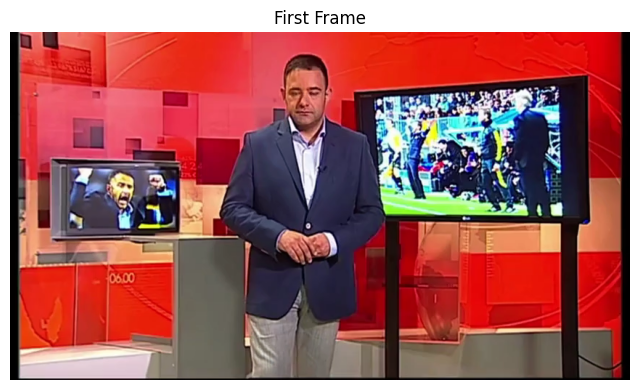

In [26]:
cap = cv2.VideoCapture(sample_video)

ret, frame = cap.read()

cap.release()

frame_rgb = cv2.cvtColor(
    frame,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))

plt.imshow(frame_rgb)

plt.axis("off")

plt.title("First Frame")

In [27]:
folders = [

    "train/real",
    "train/fake",

    "val/real",
    "val/fake",

    "test/real",
    "test/fake"

]

for folder in folders:

    os.makedirs(
        os.path.join(
            OUTPUT_PATH,
            folder
        ),
        exist_ok=True
    )

print("Output Directories Created")

Output Directories Created


# Frame Extraction Function


In [29]:
def extract_frames(video_path, interval=10):

    frames = []

    cap = cv2.VideoCapture(video_path)

    frame_count = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % interval == 0:

            frames.append(frame)

        frame_count += 1

    cap.release()

    return frames

# Test Frame Extraction

In [30]:
frames = extract_frames(sample_video)

print("Frames Extracted :", len(frames))

Frames Extracted : 81


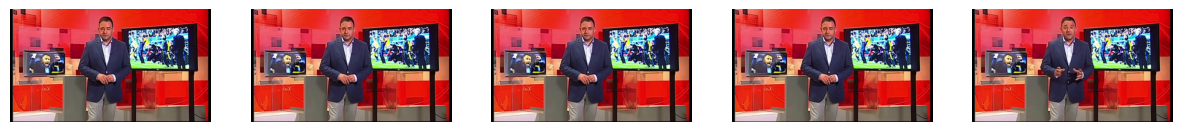

In [31]:
plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        cv2.cvtColor(
            frames[i],
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis("off")

plt.show()

# Extract Frames from One Fake Video

In [32]:
sample_fake = os.path.join(
    FAKE_PATH,
    fake_videos[0]
)

fake_frames = extract_frames(sample_fake)

print("Fake Frames :", len(fake_frames))

Fake Frames : 81


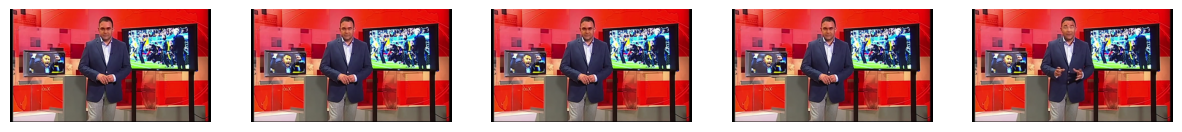

In [33]:
plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        cv2.cvtColor(
            fake_frames[i],
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis("off")

plt.show()

# Load OpenCV Face Detector

In [35]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

print("Face Detector Loaded Successfully")

Face Detector Loaded Successfully


In [36]:
def detect_face(frame):

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60,60)
    )

    return faces

In [37]:
frame = frames[0]

faces = detect_face(frame)

print("Faces Detected :", len(faces))

Faces Detected : 1


(np.float64(-0.5), np.float64(853.5), np.float64(479.5), np.float64(-0.5))

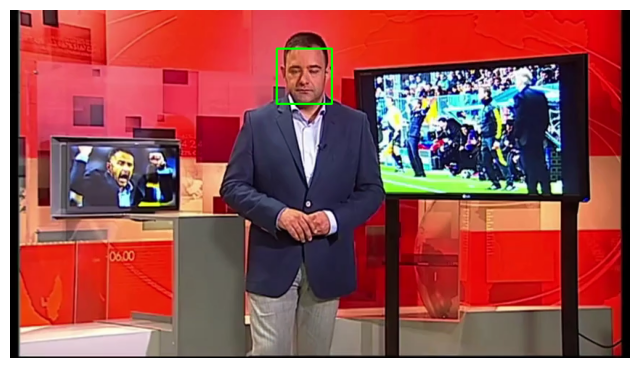

In [38]:
image = frame.copy()

for (x,y,w,h) in faces:

    cv2.rectangle(
        image,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        2
    )

plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))

plt.axis("off")

In [39]:
def crop_face(frame):

    faces = detect_face(frame)

    if len(faces)==0:

        return None

    x,y,w,h = faces[0]

    face = frame[y:y+h,x:x+w]

    face = cv2.resize(
        face,
        (299,299)
    )

    return face

(np.float64(-0.5), np.float64(298.5), np.float64(298.5), np.float64(-0.5))

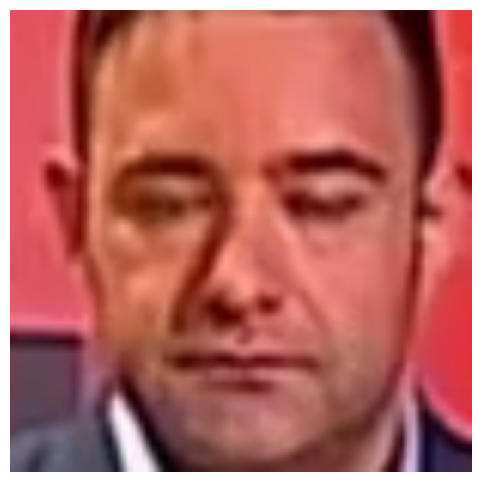

In [40]:
face = crop_face(frames[0])

plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(face,cv2.COLOR_BGR2RGB))

plt.axis("off")

In [41]:
cv2.imwrite(
    "sample_face.jpg",
    face
)

print("Saved Successfully")

Saved Successfully


In [42]:
def save_faces(video_path,
               save_folder,
               prefix,
               interval=10):

    frames = extract_frames(
        video_path,
        interval
    )

    saved = 0

    for idx,frame in enumerate(frames):

        face = crop_face(frame)

        if face is None:

            continue

        filename = f"{prefix}_{idx}.jpg"

        cv2.imwrite(

            os.path.join(
                save_folder,
                filename
            ),

            face

        )

        saved += 1

    return saved

In [43]:
test_folder = os.path.join(
    OUTPUT_PATH,
    "train",
    "real"
)

saved = save_faces(

    sample_video,

    test_folder,

    "real0"

)

print("Saved :",saved)

Saved : 81


In [44]:
images = os.listdir(test_folder)

print(images[:10])

print()

print("Total :",len(images))

['real0_0.jpg', 'real0_1.jpg', 'real0_2.jpg', 'real0_3.jpg', 'real0_4.jpg', 'real0_5.jpg', 'real0_6.jpg', 'real0_7.jpg', 'real0_8.jpg', 'real0_9.jpg']

Total : 81


(np.float64(-0.5), np.float64(298.5), np.float64(298.5), np.float64(-0.5))

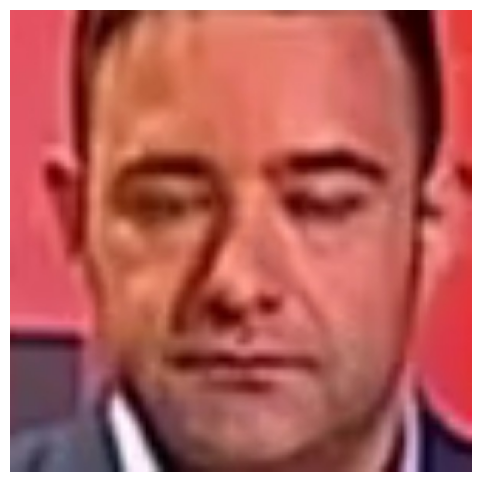

In [45]:
img = cv2.imread(

    os.path.join(
        test_folder,
        images[0]
    )

)

plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

plt.axis("off")

In [46]:
count = 0

for video in tqdm(real_videos):

    video_path = os.path.join(

        REAL_PATH,

        video

    )

    count += save_faces(

        video_path,

        os.path.join(
            OUTPUT_PATH,
            "train",
            "real"
        ),

        video[:-4]

    )

print()

print("Total Real Faces Saved :",count)

100%|██████████| 100/100 [25:15<00:00, 15.16s/it]


Total Real Faces Saved : 5195


In [47]:
count = 0

for video in tqdm(fake_videos):

    video_path = os.path.join(

        FAKE_PATH,

        video

    )

    count += save_faces(

        video_path,

        os.path.join(
            OUTPUT_PATH,
            "train",
            "fake"
        ),

        video[:-4]

    )

print()

print("Total Fake Faces Saved :",count)

100%|██████████| 100/100 [25:09<00:00, 15.10s/it]


Total Fake Faces Saved : 5198


In [48]:
real_images = os.listdir(

    os.path.join(
        OUTPUT_PATH,
        "train",
        "real"
    )

)

fake_images = os.listdir(

    os.path.join(
        OUTPUT_PATH,
        "train",
        "fake"
    )

)

print("Real Images :",len(real_images))

print("Fake Images :",len(fake_images))

Real Images : 5276
Fake Images : 5198


# Display Random Samples

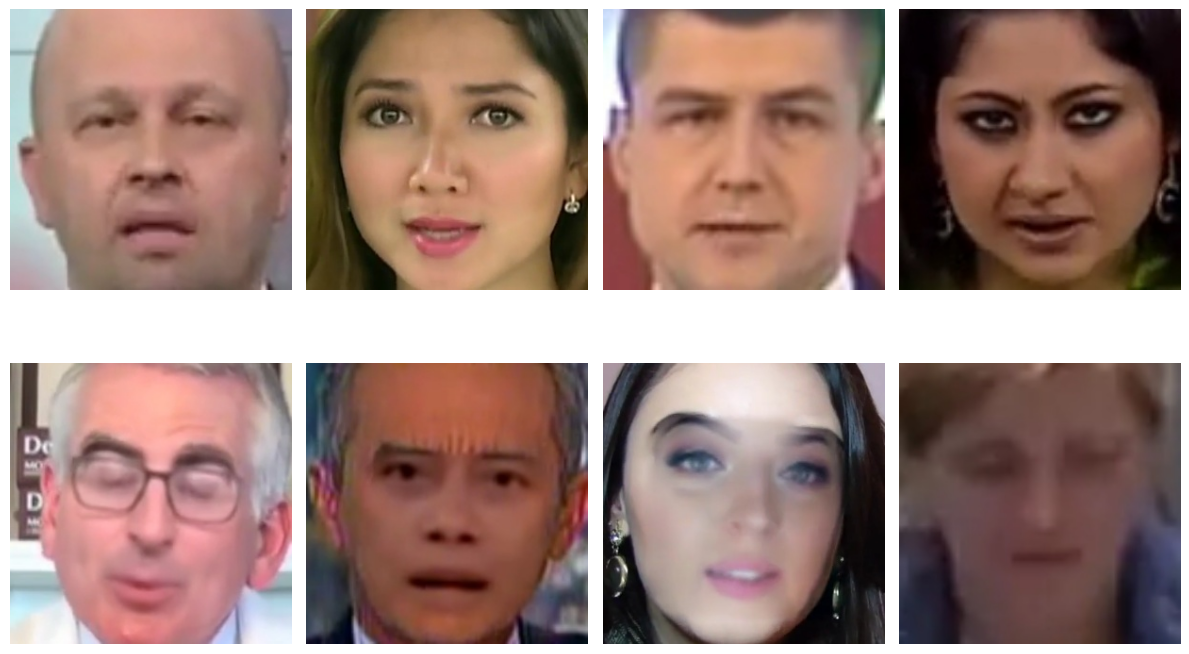

In [49]:
plt.figure(figsize=(12,8))

for i in range(8):

    if i<4:

        img = cv2.imread(

            os.path.join(

                OUTPUT_PATH,

                "train",

                "real",

                random.choice(real_images)

            )

        )

    else:

        img = cv2.imread(

            os.path.join(

                OUTPUT_PATH,

                "train",

                "fake",

                random.choice(fake_images)

            )

        )

    plt.subplot(2,4,i+1)

    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

    plt.axis("off")

plt.tight_layout()

plt.show()

In [50]:
from sklearn.model_selection import train_test_split

train_real, temp_real = train_test_split(
    real_videos,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_real, test_real = train_test_split(
    temp_real,
    test_size=0.50,
    random_state=42
)

train_fake, temp_fake = train_test_split(
    fake_videos,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_fake, test_fake = train_test_split(
    temp_fake,
    test_size=0.50,
    random_state=42
)

print("Real Videos")
print("Train :",len(train_real))
print("Validation :",len(val_real))
print("Test :",len(test_real))

print()

print("Fake Videos")
print("Train :",len(train_fake))
print("Validation :",len(val_fake))
print("Test :",len(test_fake))

Real Videos
Train : 70
Validation : 15
Test : 15

Fake Videos
Train : 70
Validation : 15
Test : 15


In [51]:
def process_dataset(video_list,
                    video_folder,
                    save_folder):

    total_saved = 0

    for video in tqdm(video_list):

        video_path = os.path.join(
            video_folder,
            video
        )

        total_saved += save_faces(
            video_path,
            save_folder,
            video[:-4]
        )

    return total_saved

# Process Training Set

In [52]:
train_real_folder = os.path.join(
    OUTPUT_PATH,
    "train",
    "real"
)

train_fake_folder = os.path.join(
    OUTPUT_PATH,
    "train",
    "fake"
)

print("Processing Training Real...")

real_train = process_dataset(
    train_real,
    REAL_PATH,
    train_real_folder
)

print()

print("Processing Training Fake...")

fake_train = process_dataset(
    train_fake,
    FAKE_PATH,
    train_fake_folder
)

print()

print("Training Images")

print("Real :",real_train)

print("Fake :",fake_train)

Processing Training Real...


100%|██████████| 70/70 [15:59<00:00, 13.71s/it]



Processing Training Fake...


100%|██████████| 70/70 [15:11<00:00, 13.02s/it]


Training Images
Real : 3515
Fake : 3517


# Process validation set

In [53]:
val_real_folder = os.path.join(
    OUTPUT_PATH,
    "val",
    "real"
)

val_fake_folder = os.path.join(
    OUTPUT_PATH,
    "val",
    "fake"
)

print("Processing Validation Real...")

real_val = process_dataset(
    val_real,
    REAL_PATH,
    val_real_folder
)

print()

print("Processing Validation Fake...")

fake_val = process_dataset(
    val_fake,
    FAKE_PATH,
    val_fake_folder
)

print()

print("Validation Images")

print("Real :",real_val)

print("Fake :",fake_val)

Processing Validation Real...


100%|██████████| 15/15 [04:29<00:00, 17.99s/it]



Processing Validation Fake...


100%|██████████| 15/15 [04:23<00:00, 17.59s/it]


Validation Images
Real : 839
Fake : 840


# Process Test set

In [54]:
test_real_folder = os.path.join(
    OUTPUT_PATH,
    "test",
    "real"
)

test_fake_folder = os.path.join(
    OUTPUT_PATH,
    "test",
    "fake"
)

print("Processing Test Real...")

real_test = process_dataset(
    test_real,
    REAL_PATH,
    test_real_folder
)

print()

print("Processing Test Fake...")

fake_test = process_dataset(
    test_fake,
    FAKE_PATH,
    test_fake_folder
)

print()

print("Test Images")

print("Real :",real_test)

print("Fake :",fake_test)

Processing Test Real...


100%|██████████| 15/15 [03:39<00:00, 14.64s/it]



Processing Test Fake...


100%|██████████| 15/15 [03:40<00:00, 14.69s/it]


Test Images
Real : 841
Fake : 841


In [55]:
for split in ["train","val","test"]:

    real = len(os.listdir(
        os.path.join(
            OUTPUT_PATH,
            split,
            "real"
        )
    ))

    fake = len(os.listdir(
        os.path.join(
            OUTPUT_PATH,
            split,
            "fake"
        )
    ))

    print(split.upper())

    print("Real :",real)

    print("Fake :",fake)

    print("-"*40)

TRAIN
Real : 5276
Fake : 5198
----------------------------------------
VAL
Real : 839
Fake : 840
----------------------------------------
TEST
Real : 841
Fake : 841
----------------------------------------


In [56]:
import pandas as pd

def create_csv(split):

    images = []

    labels = []

    real_path = os.path.join(
        OUTPUT_PATH,
        split,
        "real"
    )

    fake_path = os.path.join(
        OUTPUT_PATH,
        split,
        "fake"
    )

    for img in os.listdir(real_path):

        images.append(
            os.path.join(real_path,img)
        )

        labels.append(0)

    for img in os.listdir(fake_path):

        images.append(
            os.path.join(fake_path,img)
        )

        labels.append(1)

    df = pd.DataFrame({

        "image":images,

        "label":labels

    })

    df.to_csv(

        os.path.join(
            OUTPUT_PATH,
            split+".csv"
        ),

        index=False

    )

    return df

In [57]:
train_df = create_csv("train")

val_df = create_csv("val")

test_df = create_csv("test")

print(train_df.head())

                                               image  label
0  /content/drive/MyDrive/Deepfake_Project/Proces...      0
1  /content/drive/MyDrive/Deepfake_Project/Proces...      0
2  /content/drive/MyDrive/Deepfake_Project/Proces...      0
3  /content/drive/MyDrive/Deepfake_Project/Proces...      0
4  /content/drive/MyDrive/Deepfake_Project/Proces...      0


In [58]:
print("="*50)
print("Deepfake Dataset Summary")
print("="*50)

print()

print("Training Images :",len(train_df))

print("Validation Images :",len(val_df))

print("Testing Images :",len(test_df))

Deepfake Dataset Summary

Training Images : 10474
Validation Images : 1679
Testing Images : 1682
